    Scheme Code ISIN Div Payout/ISIN Growth ISIN Div Reinvestment  \
167      125502                           -          INF200K01V16   
168      125503                INF200K01V08                     -   
169      125505                INF200K01V40          INF200K01V57   
170      125504                INF200K01V32          INF200K01V24   
171      125498                INF200K01U41                     -   

                                           Scheme Name Net Asset Value  \
167  SBI Banking & PSU Fund - Direct Plan - Daily I...       1462.8683   
168      SBI BANKING & PSU FUND - Direct Plan - Growth       3321.1334   
169  SBI Banking & PSU Fund - Direct Plan - Monthly...       1311.1752   
170  SBI Banking & PSU Fund - Direct Plan - Weekly ...       1459.6212   
171     SBI BANKING & PSU FUND - Regular Paln - Growth       3125.5048   

            Date  
167  23-Jun-2025  
168  23-Jun-2025  
169  23-Jun-2025  
170  23-Jun-2025  
171  23-Jun-2025  


/tmp/ipython-input-4-153607950.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbi_funds['Date'] = pd.to_datetime(sbi_funds['Date'])
/tmp/ipython-input-4-153607950.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbi_funds['Net Asset Value'] = pd.to_numeric(sbi_funds['Net Asset Value'], errors='coerce')


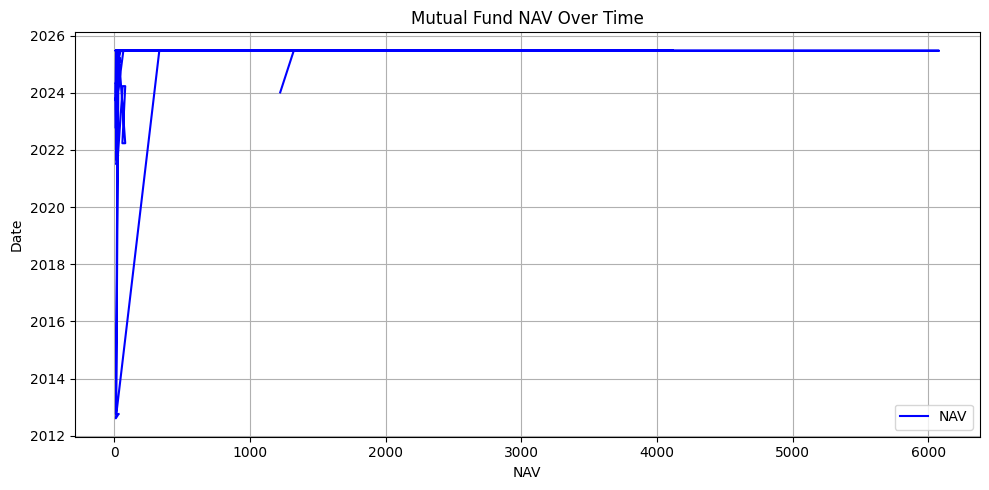

ValueError: could not convert string to float: '-'

In [ ]:
# Install required libraries
!pip install yfinance ta
import yfinance as yf
from ta.trend import MACD
from ta.volatility import BollingerBands, AverageTrueRange
import pandas as pd
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
import requests

url = 'https://www.amfiindia.com/spages/NAVAll.txt'
response = requests.get(url)

# Clean and parse
data = response.text.splitlines()
data = [line for line in data if line.strip() != '' and not line.startswith('#')]

# Convert to DataFrame
nav_data = [line.split(';') for line in data]
columns = ['Scheme Code', 'ISIN Div Payout/ISIN Growth', 'ISIN Div Reinvestment',
           'Scheme Name', 'Net Asset Value', 'Date']
df = pd.DataFrame(nav_data, columns=columns)

# Example: Filter for SBI Mutual Funds
sbi_funds = df[df['Scheme Name'].str.contains('SBI', case=False, na=False)]
print(sbi_funds.head())
# Plot NAV over time
plt.figure(figsize=(10, 5))
# Convert date and NAV
sbi_funds['Date'] = pd.to_datetime(sbi_funds['Date'])
sbi_funds['Net Asset Value'] = pd.to_numeric(sbi_funds['Net Asset Value'], errors='coerce')

plt.plot(sbi_funds['Net Asset Value'],sbi_funds['Date'], label='NAV', color='blue')

plt.title("Mutual Fund NAV Over Time")
plt.ylabel("Date")
plt.xlabel("NAV")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# Example: assume sbi_funds is already loaded and looks like this:
# sbi_funds = pd.read_csv("sbi_fund_data.csv", parse_dates=["Date"], index_col="Date")

# Drop missing values
requests.get(url)== sbi_funds['Net Asset Value'].dropna()

# Check if data is non-stationary
adf_result = adfuller(sbi_funds)
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
if adf_result[1] > 0.05:
    print("Series is non-stationary. Differencing needed (d=1).")
else:
    print("Series is stationary. No differencing needed (d=0).")

# Fit ARIMA model
model = ARIMA(requests.get(url), order=(2, 1, 2))  # (p=2, d=1, q=2)
model_fit = model.fit()

# Summary
print(model_fit.summary())

# Plot original data
plt.figure(figsize=(14, 7))
plt.plot(requests.get(url).index, requests.get(url), label='Historical Price', color='blue')

# Forecast next 5 periods (days if data is daily)
forecast = model_fit.forecast(steps=15)
forecast_index = pd.date_range(start=requests.get(url).index[-1], periods=16, freq='D')[1:]
plt.plot(forecast_index, forecast, label='Forecast', color='red', linestyle='--', marker='h')

# Optional: Confidence intervals
# conf_int = model_fit.get_forecast(steps=5).conf_int()
# plt.fill_between(forecast_index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3)

plt.title('SBI Fund Price Forecast using ARIMA(2,1,2)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

from datetime import datetime

import pandas as pd

# Ensure Date index is datetime
sbi_funds.index = pd.to_datetime(sbi_funds.index, errors='coerce')
sbi_funds = sbi_funds.sort_index()
sbi_funds = sbi_funds[~sbi_funds.index.isna()]

# Get last date in dataset
last_date = sbi_funds.index.max()

# Target forecast date
target_date = pd.Timestamp("2025-12-31")

# ✅ Convert both to datetime.date before subtracting
days_to_forecast = (target_date.date() - last_date.date()).days

print(f"Forecasting {days_to_forecast} days ahead (from {last_date.date()} to {target_date.date()})")


print(f"Forecasting {days_to_forecast} days ahead")

# Fit model again if needed
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(sbi_funds['Net Asset Value'], order=(2, 1, 2))
model_fit = model.fit()

# Forecast till 2025
forecast = model_fit.forecast(steps=days_to_forecast)

# Create future index
forecast_index = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=days_to_forecast, freq='D')

# Create DataFrame with predictions
forecast_df = pd.DataFrame({'Forecasted NAV': forecast}, index=forecast_index)

# Get predicted NAV for 2025-12-31
predicted_nav_2025 = forecast_df.loc["2025-12-31"]
print("\n📈 Predicted NAV on 2025-12-31:", predicted_nav_2025.values[0])

plt.figure(figsize=(14, 7))
plt.plot(sbi_funds.index, sbi_funds['Net Asset Value'], label='Historical NAV')
plt.plot(forecast_df.index, forecast_df['Forecasted NAV'], color='red', label='Forecasted NAV')
plt.axvline(pd.Timestamp("2025-12-31"), color='green', linestyle='--', label='Target Date')
plt.title("SBI Fund NAV Forecast to 2025")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



Forecasting 20453 days ahead (from 1970-01-01 to 2025-12-31)
Forecasting 20453 days ahead


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p


📈 Predicted NAV on 2025-12-31: [nan]


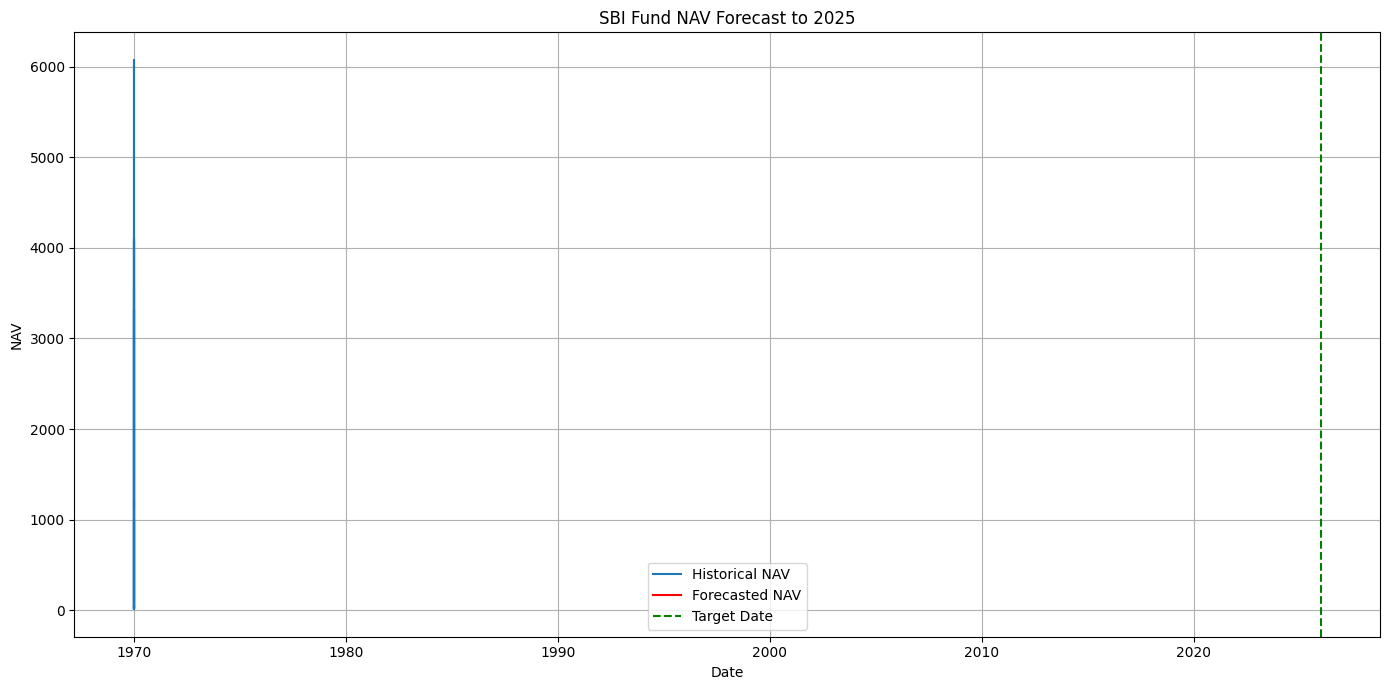

In [ ]:
from datetime import datetime

import pandas as pd

# Ensure Date index is datetime
sbi_funds.index = pd.to_datetime(sbi_funds.index, errors='coerce')
sbi_funds = sbi_funds.sort_index()
sbi_funds = sbi_funds[~sbi_funds.index.isna()]

# Get last date in dataset
last_date = sbi_funds.index.max()

# Target forecast date
target_date = pd.Timestamp("2025-12-31")

# ✅ Convert both to datetime.date before subtracting
days_to_forecast = (target_date.date() - last_date.date()).days

print(f"Forecasting {days_to_forecast} days ahead (from {last_date.date()} to {target_date.date()})")


print(f"Forecasting {days_to_forecast} days ahead")

# Fit model again if needed
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(sbi_funds['Net Asset Value'], order=(2, 1, 2))
model_fit = model.fit()

# Forecast till 2025
forecast = model_fit.forecast(steps=days_to_forecast)

# Create future index
forecast_index = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=days_to_forecast, freq='D')

# Create DataFrame with predictions
forecast_df = pd.DataFrame({'Forecasted NAV': forecast}, index=forecast_index)

# Get predicted NAV for 2025-12-31
predicted_nav_2025 = forecast_df.loc["2025-12-31"]
print("\n📈 Predicted NAV on 2025-12-31:", predicted_nav_2025.values[0])

plt.figure(figsize=(14, 7))
plt.plot(sbi_funds.index, sbi_funds['Net Asset Value'], label='Historical NAV')
plt.plot(forecast_df.index, forecast_df['Forecasted NAV'], color='red', label='Forecasted NAV')
plt.axvline(pd.Timestamp("2025-12-31"), color='green', linestyle='--', label='Target Date')
plt.title("SBI Fund NAV Forecast to 2025")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import requests

# Load data
url = 'https://www.amfiindia.com/spages/NAVAll.txt'
response = requests.get(url)
lines = response.text.splitlines()
lines = [line for line in lines if line.strip() and not line.startswith('#')]
nav_data = [line.split(';') for line in lines]

# Columns and DataFrame
columns = ['Scheme Code', 'ISIN Div Payout/ISIN Growth', 'ISIN Div Reinvestment',
           'Scheme Name', 'Net Asset Value', 'Date']
df = pd.DataFrame(nav_data, columns=columns)

# Filter a valid SBI scheme
scheme_name = 'SBI Bluechip Fund - Direct Plan - Growth'
sbi = df[df['Scheme Name'].str.contains(scheme_name, case=False, na=False)].copy()

# Convert to numeric/date
sbi['Net Asset Value'] = pd.to_numeric(sbi['Net Asset Value'], errors='coerce')
sbi['Date'] = pd.to_datetime(sbi['Date'], errors='coerce')
sbi = sbi.dropna(subset=['Net Asset Value', 'Date'])
sbi = sbi.sort_values('Date')
sbi.set_index('Date', inplace=True)

# Final check
print("✅ Final date range:", sbi.index.min(), "to", sbi.index.max())

from statsmodels.tsa.arima.model import ARIMA
from datetime import datetime
import matplotlib.pyplot as plt

# Fit ARIMA
model = ARIMA(sbi['Net Asset Value'], order=(2, 1, 2))
model_fit = model.fit()

# Forecast days
last_date = sbi.index.max()
target_date = pd.Timestamp("2025-12-31")
days_to_forecast = (target_date.date() - last_date.date()).days

# Forecast
forecast = model_fit.forecast(steps=days_to_forecast)
forecast_index = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=days_to_forecast, freq='D')
forecast_df = pd.DataFrame({'Forecasted NAV': forecast}, index=forecast_index)

# Plot
plt.figure(figsize=(14, 7))
plt.plot(sbi.index, sbi['Net Asset Value'], label='Historical NAV', color='blue')
plt.plot(forecast_df.index, forecast_df['Forecasted NAV'], color='red', label='Forecasted NAV')
plt.axvline(pd.Timestamp("2025-12-31"), color='green', linestyle='--', label='Target Date')
plt.title("SBI Fund NAV Forecast to 2025")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


✅ Final date range: NaT to NaT


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observa

LinAlgError: Schur decomposition solver error.

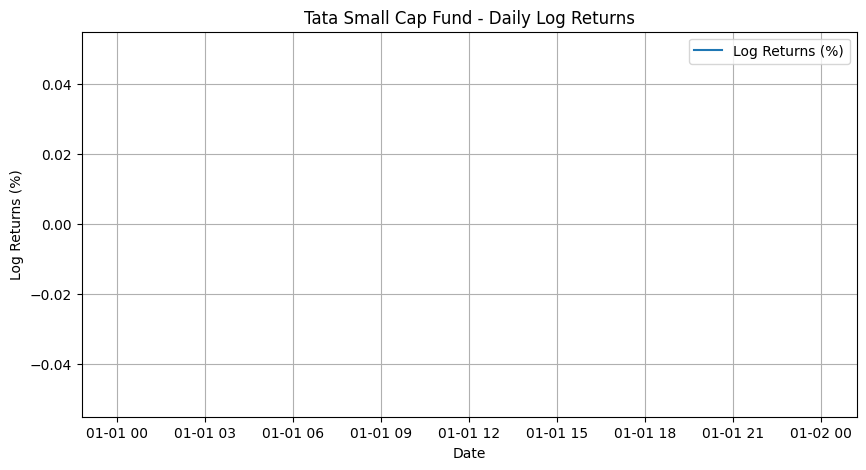

In [ ]:
import pandas as pd
import numpy as np
import requests
from io import StringIO

# Step 1: Get the latest NAV file
url = "https://www.amfiindia.com/spages/NAVAll.txt"
response = requests.get(url)
data = response.content.decode('utf-8')

# Step 2: Parse the text data into a DataFrame
df = pd.read_csv(StringIO(data), sep=';')
df.columns = df.columns.str.strip()

# Step 3: Filter for Tata Small Cap Fund (Scheme Code: 148735)
df = df.dropna(subset=['Scheme Code'])
df['Scheme Code'] = df['Scheme Code'].astype(str)

# Filter for Tata Small Cap Fund
fund_df = df[df['Scheme Code'] == '148735'][['Scheme Name', 'Net Asset Value', 'Date']]
fund_df['Date'] = pd.to_datetime(fund_df['Date'], format='%d-%b-%Y')
fund_df['Net Asset Value'] = pd.to_numeric(fund_df['Net Asset Value'], errors='coerce')

# Step 4: Sort and calculate returns
fund_df = fund_df.sort_values('Date')
fund_df.set_index('Date', inplace=True)

# Compute daily log returns
fund_df['Log Returns (%)'] = 100 *np.log(fund_df['Net Asset Value'] / fund_df['Net Asset Value'].shift(1))
fund_df.dropna(inplace=False)

# Step 5: Plotting
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(fund_df.index, fund_df['Log Returns (%)'], label='Log Returns (%)')
plt.title('Tata Small Cap Fund - Daily Log Returns')
plt.xlabel('Date')
plt.ylabel('Log Returns (%)')
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
# STEP 1: Upload Excel file
from google.colab import files
uploaded = files.upload()

# STEP 2: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings("ignore")

# STEP 3: Load and clean data
def load_and_clean_data(file_path):
    try:
        # Load raw data
        df_raw = pd.read_excel(file_path)

        # Display raw structure for debugging
        print("Raw data sample:")
        print(df_raw.head(10))

        # Find where actual data starts (skip metadata)
        data_start = 0
        for i in range(min(10, len(df_raw))):
            if pd.api.types.is_numeric_dtype(df_raw.iloc[i, 1]):
                data_start = i
                break

        # Create clean dataframe
        df = df_raw.iloc[data_start:].copy()
        df.columns = df.iloc[0]  # Set first row as header
        df = df.iloc[1:].reset_index(drop=True)

        # Clean column names
        df.columns = [col.strip() for col in df.columns]

        # Identify date and NAV columns (case insensitive)
        date_col = [col for col in df.columns if 'date' in col.lower()][0]
        nav_col = [col for col in df.columns if 'nav' in col.lower()][0]

        # Keep only necessary columns
        df = df[[date_col, nav_col]].copy()
        df.columns = ['Date', 'NAV']

        # Convert data types
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
        df['NAV'] = pd.to_numeric(df['NAV'], errors='coerce')

        # Drop rows with invalid data
        df = df.dropna(subset=['Date', 'NAV'])

        # Set date as index and sort
        df = df.set_index('Date').sort_index()

        return df

    except Exception as e:
        print(f"Error loading data: {str(e)}")
        return None

# Load data
df = load_and_clean_data("DSP Mutual Fund-NAVs-Report.xlsx")

if df is None:import pandas as pd

df_raw = pd.read_excel("DSP Mutual Fund-NAVs-Report.xlsx")

# Step 1: Remove top metadata rows
df = df_raw.iloc[4:].copy()
df.columns = df.iloc[0]       # Set actual header
df = df[1:].reset_index(drop=True)
df.columns = df.columns.str.strip()

# Step 2: Rename columns
df.rename(columns={'NAV Value': 'NAV'}, inplace=True)

# Step 3: Convert types
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['NAV'] = pd.to_numeric(df['NAV'], errors='coerce')

# Step 4: Drop invalid rows
df = df.dropna(subset=['Date', 'NAV'])

# Step 5: Confirm data loaded
if df.empty:
    raise ValueError("Failed to load and clean data")
else:
    print(df[['Date', 'NAV']].head())


# STEP 4: Exploratory Analysis
print("\nData Overview:")
print(f"Time Period: {df.index.min()} to {df.index.max()}")
print(f"Total Records: {len(df)}")
print(df.head())

plt.figure(figsize=(12, 5))
plt.plot(df['NAV'], label='Historical NAV')
plt.title('DSP Mutual Fund NAV History')
plt.xlabel('Date')
plt.ylabel('NAV Value')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# STEP 5: Check Stationarity
def check_stationarity(series):
    result = adfuller(series.dropna())
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {value}')

print("\nStationarity Check:")
check_stationarity(df['NAV'])

# STEP 6: Find Optimal ARIMA Parameters
print("\nFinding optimal ARIMA parameters...")
auto_model = auto_arima(df['NAV'],
                        seasonal=False,
                        trace=True,
                        error_action='ignore',
                        suppress_warnings=True,
                        stepwise=True)

print(auto_model.summary())

# STEP 7: Build and Fit ARIMA Model
order = auto_model.order  # Use auto-selected order
print(f"\nFitting ARIMA{order} model...")

model = ARIMA(df['NAV'], order=order)
model_fit = model.fit()

print(model_fit.summary())

# STEP 8: Forecast
forecast_steps = 30
forecast = model_fit.forecast(steps=forecast_steps)
forecast_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=forecast_steps)

# STEP 9: Plot Results
plt.figure(figsize=(14, 6))
plt.plot(df['NAV'], label='Historical NAV')
plt.plot(forecast_dates, forecast, label='Forecasted NAV', color='red', linestyle='--')
plt.fill_between(forecast_dates,
                 forecast * 0.95,
                 forecast * 1.05,
                 color='red', alpha=0.1, label='Confidence Interval')
plt.title(f'DSP Mutual Fund NAV Forecast (Next {forecast_steps} Days)')
plt.xlabel('Date')
plt.ylabel('NAV Value')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# STEP 10: Output Forecast Table
forecast_df = pd.DataFrame({
    'Date': forecast_dates,
    'Forecasted NAV': forecast,
    'Lower Bound': forecast * 0.95,
    'Upper Bound': forecast * 1.05
}).set_index('Date')

print("\nForecast Results:")
print(forecast_df.head(10))

Saving DSP Mutual Fund-NAVs-Report.xlsx to DSP Mutual Fund-NAVs-Report (4).xlsx
Raw data sample:
                                          Unnamed: 0 Unnamed: 1  Unnamed: 2
0                 DSP Mutual Fund NAVs on 23-06-2025        NaN         NaN
1                              AMC:- DSP Mutual Fund        NaN         NaN
2                                  Date:- 23-06-2025        NaN         NaN
3                                        Scheme Name   NAV (Rs)    NAV Date
4          DSP 10Y G-Sec Fund - Direct Plan - Growth    22.4594  23-06-2025
5            DSP 10Y G-Sec Fund - Direct Plan - IDCW    10.8668  23-06-2025
6  DSP 10Y G-Sec Fund - Direct Plan - IDCW - Monthly    10.5395  23-06-2025
7  DSP 10Y G-Sec Fund - Direct Plan - IDCW - Quar...    11.1174  23-06-2025
8         DSP 10Y G-Sec Fund - Regular Plan - Growth    21.9234  23-06-2025
9           DSP 10Y G-Sec Fund - Regular Plan - IDCW    10.6605  23-06-2025
Error loading data: 'float' object has no attribute 'strip'


ValueError: Failed to load and clean data